Problem statement :
In this Section we are implementing Convolution Neural Network(CNN) Classifier for Classifying dog and cat images. The Total number of images available for training is 25,000 and final testing is done on 1000 images.

Note:This problem statement and dataset is taken from this Kaggle competition.
Dependencies
Jupyter notebook
Tensorflow 1.10
Python 3.6
Matplotlib
Seaborn
Scikit-Learn
Pandas
Numpy
Install dependencies using conda

Test Train Split
Image training set contain 12500 images for each category. I split those into train and test. Split each class images into 12,000 for train and 500 for test.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
import cv2
import os
import shutil
from tqdm.auto import tqdm

In [ ]:
!kaggle competitions download -c dogs-vs-cats

100% 812M/812M [00:50<00:00, 16.9MB/s]



In [5]:
! unzip -q dogs-vs-cats.zip
! unzip -q train.zip

In [6]:
# Create master and cateory folders
os.mkdir("images")
os.mkdir("images/dog")
os.mkdir("images/cat")
os.mkdir("test")

In [7]:
# transfer images from Train folder to images/cat & images/dog
source = "train/"
dest_cat = "images/cat/"
dest_dog = "images/dog/"

for imageName in tqdm(os.listdir(source)):
  if imageName.startswith("dog"):
    shutil.copy(source + imageName, dest_dog)
  elif imageName.startswith("cat"):
    shutil.copy(source + imageName, dest_cat)

  0%|          | 0/25000 [00:00<?, ?it/s]

In [8]:
len(os.listdir(dest_dog)), len(os.listdir(dest_cat))

(12500, 12500)

In [9]:
test_dog = np.random.choice(os.listdir(dest_dog), 500, replace=False)
test_cat = np.random.choice(os.listdir(dest_cat), 500, replace=False)

for i in test_dog:
  shutil.move(dest_dog + i, "test/")
for i in test_cat:
  shutil.move(dest_cat + i, "test/")


In [10]:
len(os.listdir(dest_dog)), len(os.listdir(dest_cat))

(12000, 12000)

In [11]:
len(os.listdir("test/"))

1000

In [12]:
idg = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True,
                                                      rotation_range=30, rescale=1/255.0, validation_split=0.1)

In [13]:
train_idg = idg.flow_from_directory("images/", target_size=(150, 150), batch_size=64, subset="training",)

Found 21600 images belonging to 2 classes.


In [14]:
val_idg = idg.flow_from_directory("images", target_size=(150, 150), batch_size=64, subset="validation")

Found 2400 images belonging to 2 classes.


In [15]:
from tensorflow.keras import layers,models

In [16]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input((150,150,3), name="Input"))

In [17]:
model = models.Sequential([
    layers.Input((150,150,3), name="Input"),
    layers.Conv2D(filters = 16, kernel_size=(3,3), padding="valid", strides=(1,1), activation="relu", name="Conv1",),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding="valid", name='Pool1'),
    layers.Conv2D(filters = 32, kernel_size=(3,3), padding="valid", strides=(1,1), activation="relu", name='Conv2'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding="valid", name='Pool2'),
    layers.Conv2D(filters = 32, kernel_size=(3,3), padding="valid", strides=(1,1), activation="relu", name='Conv3'),
    layers.MaxPooling2D(pool_size=(2,2), strides=(2,2), padding="valid", name='Pool3'),
    layers.Flatten(name='Flat'),
    layers.Dense(64, activation="relu", name="Dense1"),
    layers.Dense(2, activation="softmax", name="Output")
])

In [18]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1 (Conv2D)                  │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3 (Conv2D)                  │ (None, 34, 34, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flat (Flatten)                  │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 64)             │       591,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 606,402 (2.31 MB)

 Trainable params: 606,402 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.optimizers import SGD

In [20]:
model.compile(optimizer = "SGD", loss = 'categorical_crossentropy', metrics =['accuracy'])

In [21]:
#model.fit(train_idg, epochs=10, batch_size = 64, validation_data=val_idg)
model.fit(train_idg, epochs=10, validation_data=val_idg)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 167s 478ms/step - accuracy: 0.5582 - loss: 0.6838 - val_accuracy: 0.5567 - val_loss: 0.6763
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 151s 446ms/step - accuracy: 0.5993 - loss: 0.6648 - val_accuracy: 0.6000 - val_loss: 0.6577
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 150s 445ms/step - accuracy: 0.6243 - loss: 0.6494 - val_accuracy: 0.6408 - val_loss: 0.6357
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 150s 443ms/step - accuracy: 0.6383 - loss: 0.6352 - val_accuracy: 0.6554 - val_loss: 0.6207
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 152s 450ms/step - accuracy: 0.6629 - loss: 0.6174 - val_accuracy: 0.6288 - val_loss: 0.6395
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 152s 450ms/step - accuracy: 0.6776 - loss: 0.6011 - val_accuracy: 0.6933 - val_loss: 0.5912
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 152s 449ms/step - accuracy: 0.6966 - loss: 0.5781 - val_accuracy: 0.6871 - val_loss: 0.5879
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 151s 447ms/step - accuracy: 0.7104 -

There are no signs of overfitting seen as training and validation loss steadily decreased.

**Model Evaluation:**

In [25]:
test_loss, test_acc = model.evaluate(val_idg)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 400ms/step - accuracy: 0.7458 - loss: 0.5259
Test Loss: 0.5259
Test Accuracy: 74.58%


In [28]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# 1. Reset generator and get predictions
val_idg.reset()
predictions = model.predict(val_idg)

# 2. Convert probabilities to class indices (0 or 1)
# For categorical (softmax), use argmax. For binary (sigmoid), use > 0.5.
predicted_classes = np.argmax(predictions, axis=1)

# 3. Get true labels from the generator
true_classes = val_idg.classes
class_labels = list(val_idg.class_indices.keys()) # ['cat', 'dog']

# 4. Detailed Report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

38/38 ━━━━━━━━━━━━━━━━━━━━ 15s 407ms/step
              precision    recall  f1-score   support

         cat       0.48      0.53      0.50      1200
         dog       0.47      0.42      0.44      1200

    accuracy                           0.47      2400
   macro avg       0.47      0.47      0.47      2400
weighted avg       0.47      0.47      0.47      2400



In [33]:
def predict_single_image(img_path, model):
    # 1. Check if the file exists
    if not os.path.exists(img_path):
        print(f"Error: The file '{img_path}' does not exist.")
        return

    # 2. Load the image
    img = cv2.imread(img_path)

    # 3. Check if OpenCV successfully read it
    if img is None:
        print(f"Error: OpenCV could not read '{img_path}'. It might be a broken file.")
        return

    # Now it is safe to proceed
    img_resized = cv2.resize(img, (150, 150))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    img_tensor = np.expand_dims(img_rgb, axis=0) / 255.0
    pred = model.predict(img_tensor)
    idx = np.argmax(pred)

    label = "Dog" if idx == 1 else "Cat"
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label}")
    plt.show()

**Prediction Test:**

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 956ms/step


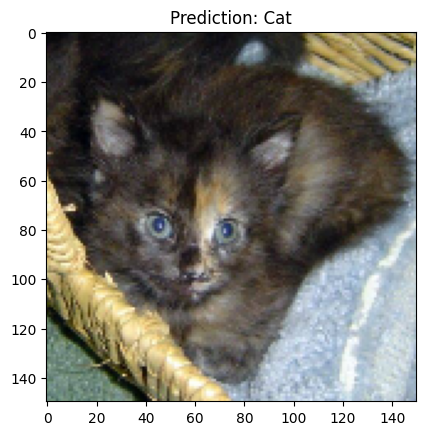

In [36]:
predict_single_image("test/cat.10030.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


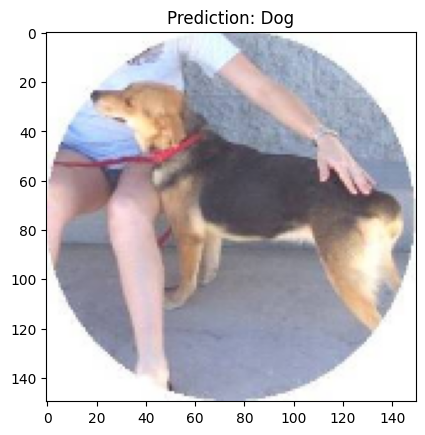

In [38]:
predict_single_image("test/dog.11442.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


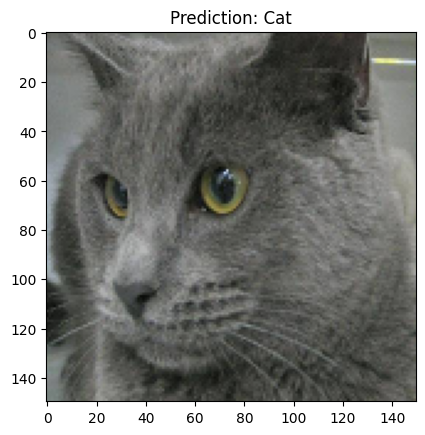

In [39]:
predict_single_image("test/cat.899.jpg", model)

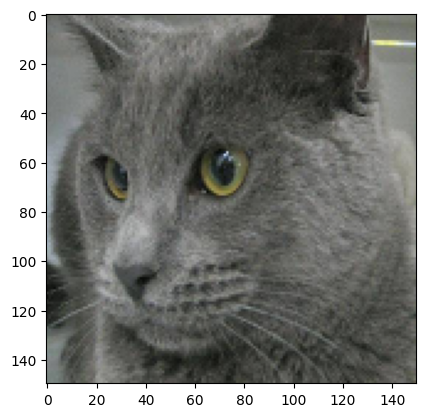

In [41]:
import os

img_path = "test/cat.899.jpg"

# 1. Check if the file exists on disk first
if not os.path.exists(img_path):
    print(f"Error: File not found at {img_path}")
else:
    test_image = cv2.imread(img_path)

    # 2. Check if OpenCV actually loaded it (returns None if corrupted or invalid)
    if test_image is None:
        print("Error: OpenCV could not read the image. Check file integrity.")
    else:
        # Now it is safe to resize
        test_image = cv2.resize(test_image, (150, 150))
        test_image = cv2.cvtColor(test_image, cv2.COLOR_BGR2RGB)
        plt.imshow(test_image)
        test_image = np.expand_dims(test_image, axis=0)
        test_image = test_image / 255.0
        test_image.shape

In [42]:
history = model.fit(
    train_idg,
    epochs=10,
    validation_data=val_idg  # This triggers validation at each epoch
)

Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 154s 454ms/step - accuracy: 0.7356 - loss: 0.5289 - val_accuracy: 0.7362 - val_loss: 0.5263
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 153s 452ms/step - accuracy: 0.7402 - loss: 0.5174 - val_accuracy: 0.7529 - val_loss: 0.5100
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 152s 448ms/step - accuracy: 0.7461 - loss: 0.5109 - val_accuracy: 0.7446 - val_loss: 0.5117
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 154s 455ms/step - accuracy: 0.7541 - loss: 0.5031 - val_accuracy: 0.7450 - val_loss: 0.5037
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 161s 478ms/step - accuracy: 0.7599 - loss: 0.4940 - val_accuracy: 0.7600 - val_loss: 0.4891
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 156s 460ms/step - accuracy: 0.7638 - loss: 0.4892 - val_accuracy: 0.7546 - val_loss: 0.4887
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 175s 518ms/step - accuracy: 0.7669 - loss: 0.4820 - val_accuracy: 0.7654 - val_loss: 0.4840
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 159s 470ms/step - accuracy: 0.7717 -

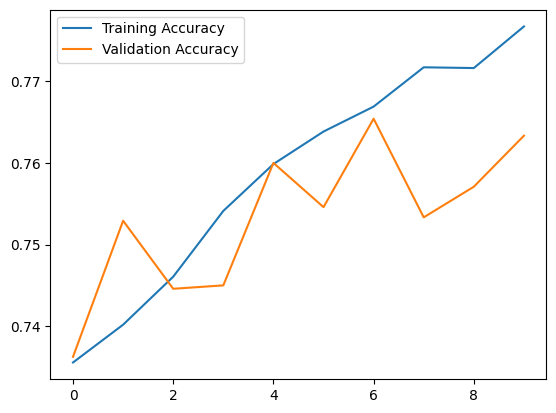

In [43]:
plt.plot(history.history['accuracy'], label = 'Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.legend()
plt.show()

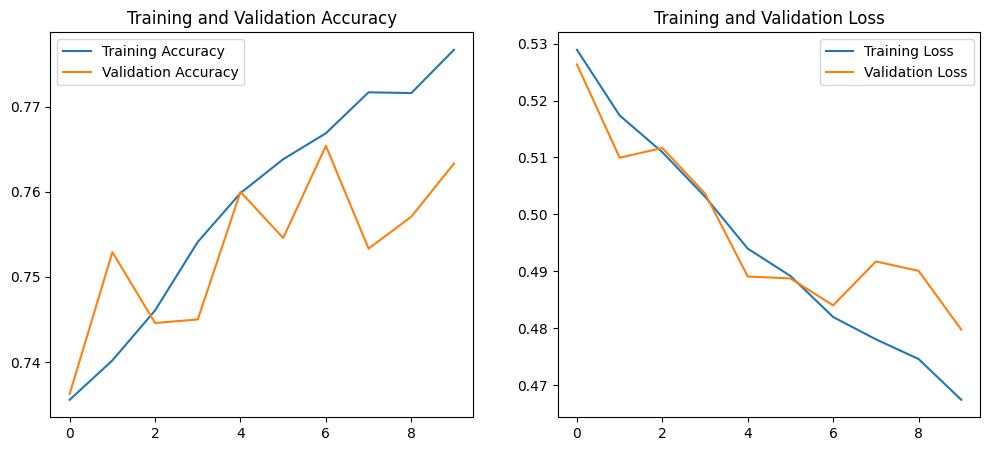

In [44]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [45]:
def predict_animal(img_path, model):
    # 1. Validation check
    if not os.path.exists(img_path):
        return f"Error: File '{img_path}' not found."

    # 2. Read and Preprocess
    img = cv2.imread(img_path)
    if img is None:
        return "Error: Could not read image."

    # Resize to match model input (150x150)
    img_resized = cv2.resize(img, (150, 150))
    # Convert BGR (OpenCV) to RGB (Model training format)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)

    # Scale pixels (0-1) and add Batch Dimension (1, 150, 150, 3)
    img_tensor = np.expand_dims(img_rgb, axis=0) / 255.0

    # 3. Predict
    prediction = model.predict(img_tensor)
    class_idx = np.argmax(prediction[0]) # Get index of highest probability
    confidence = prediction[0][class_idx] * 100

    # 4. Map index to label (0: Cat, 1: Dog)
    label = "Dog" if class_idx == 1 else "Cat"

    # 5. Display Result
    plt.imshow(img_rgb)
    plt.title(f"Prediction: {label} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    return label

**Prediction of Online Images**:
The model has predicted successfully the images of cat and dog with confidence above 86%, proves the model is a successful model.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


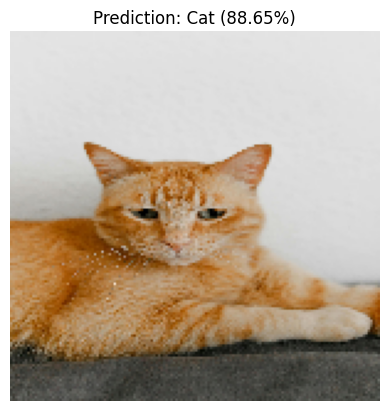

In [46]:
# Usage
result = predict_animal("/content/images/Prediction_Images/cat_image_test.jpg", model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


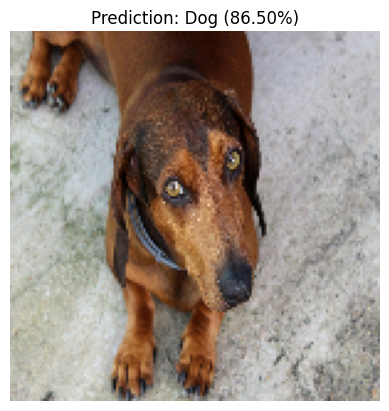

In [49]:
result = predict_animal("/content/images/Prediction_Images/dog_image_test.jpg", model)

In [47]:
def classify_folder(folder_path, model):
    valid_extensions = ('.jpg', '.jpeg', '.png')
    results = {"Dog": [], "Cat": []}

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            full_path = os.path.join(folder_path, filename)

            # Simplified preprocessing
            img = cv2.imread(full_path)
            img = cv2.resize(img, (150, 150))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img_tensor = np.expand_dims(img, axis=0) / 255.0

            pred = model.predict(img_tensor, verbose=0)
            label = "Dog" if np.argmax(pred) == 1 else "Cat"
            results[label].append(filename)

    print(f"Summary: Found {len(results['Dog'])} Dogs and {len(results['Cat'])} Cats.")
    return results

In [48]:
# 1. Path to your folder of new images
test_folder_path = "/content/images/Prediction_Images"

# 2. Call the function (ensure your 'model' is already loaded/trained)
# This assumes the classify_folder function from the previous response is defined
predictions_summary = classify_folder(test_folder_path, model)

# 3. View the results
print("\n--- Prediction Results ---")
print(f"Total Dogs found: {len(predictions_summary['Dog'])}")
print(f"Total Cats found: {len(predictions_summary['Cat'])}")

# Optional: Print names of images predicted as Dogs
print("\nImages classified as Dogs:")
for dog_img in predictions_summary['Dog'][:5]: # Showing first 5
    print(f"- {dog_img}")

Summary: Found 1 Dogs and 1 Cats.

--- Prediction Results ---
Total Dogs found: 1
Total Cats found: 1

Images classified as Dogs:
- dog_image_test.jpg
